# qiu_2026 — in-silico analyses

Probes a trained `qiu_2026` digital twin with *synthetic* stimuli, rather than scoring it against
recordings (that is `qiu_2026_inspect_predictions.ipynb`).

Two analyses, chosen because the qiu model has two distinct behavioral pathways:

1. **MEIs per bouton.** Most-exciting-input optimization for individual axonal boutons, repeated at
   the two behavioral states the animal actually occupies, with the optimization's own diagnostics
   (convergence trace, gradient support, contrast delivered inside the receptive field) reported
   alongside — an MEI is an optimizer's output before it is a statement about a cell.
2. **Behavior-state modulation.** Sweeps of the behavior input channels (pupil size, locomotion) and
   of the pupil shifter's eye position.

**Why both.** The behavior channels are broadcast constant over height and width
(`data_io/qiu_2026/stimuli.py`), so they reach the core only through the first convolution's
input-channel weights — a constant per-output-channel offset ahead of BatchNorm and ELU. A
state-dependent bias before a nonlinearity is the *only* mechanism this architecture has for
behavioral gain: it can rescale or threshold a response, but it cannot reshape a receptive field.
The pupil-position shifter is the one pathway that can actually *move* a receptive field. Running
both separates gain from displacement.

**How to use.** Set `SESSION` / `CKPT_PATH` in the config cell (defaults auto-pick the newest
checkpoint), then run all cells.

This notebook needs a GPU and the dataset. Once it has run once, `qiu_2026_insilico_from_disk.ipynb`
reproduces every figure below from the saved `.npz` files alone — no model, no dataset, seconds on a
laptop. Use that one to explore the results; use this one to change how they are computed.

In [ ]:
# Inline backend, so figures are captured as cell outputs when this notebook is executed
# headlessly (nbconvert on the cluster). Without it a non-interactive backend silently
# swallows every plot.
%matplotlib inline

import json
import os
from pathlib import Path

import hydra
import matplotlib.pyplot as plt
import numpy as np
import torch
from hydra import compose, initialize_config_dir

from openretina.utils.file_utils import get_cache_directory
from openretina.models.core_readout import load_core_readout_model

# ---- config: edit these ----
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SESSION = None      # None -> the model's first readout head
CKPT_PATH = None    # None -> auto-pick the newest checkpoint under the latest run
N_BOUTONS = 24      # boutons to compute MEIs for (17.3k in total; pick a handful)
# The MEI is exactly as long as the objective can reach: the unpadded core cuts 18 frames
# (sum(k-1) over temporal_kernel_sizes [11, 5, 5]), so 18 + RESPONSE_WINDOW leaves no input frame
# outside the response window's causal cone. At 50 frames, 22 of them were unreachable and stayed at
# their random-init value while consuming a quarter of the norm budget.
RESPONSE_WINDOW = 10          # output frames to maximize, at 30 Hz
MEI_TIME_STEPS = 18 + RESPONSE_WINDOW

# Every MEI knob below can be overridden from the environment, so one notebook produces any variant
# without being edited -- `run_qiu_insilico_variant.sh` sets these. The defaults are the baseline run.
MEI_RMS_FACTOR = float(os.environ.get("MEI_RMS_FACTOR", 1.0))        # norm target / training-video RMS
SMOOTHNESS_SPATIAL = float(os.environ.get("MEI_SMOOTHNESS_SPATIAL", 0.0))
SMOOTHNESS_TEMPORAL = float(os.environ.get("MEI_SMOOTHNESS_TEMPORAL", 0.0))

# Results land in RESULTS_ROOT/<session>/<MEI_VARIANT>, or directly in RESULTS_ROOT/<session> when
# unset. Variants keep runs at different settings side by side instead of overwriting each other --
# the comparison between them is the whole point.
MEI_VARIANT = os.environ.get("MEI_VARIANT") or None
# ----------------------------

os.environ.setdefault("OPENRETINA_CACHE_DIRECTORY", str(get_cache_directory()))
device = "cuda" if torch.cuda.is_available() else "cpu"
print("repo: ", REPO)
print("device:", device, "| cache:", os.environ["OPENRETINA_CACHE_DIRECTORY"])
print(f"MEI knobs: rms_factor={MEI_RMS_FACTOR:g} smoothness=({SMOOTHNESS_SPATIAL:g}, "
      f"{SMOOTHNESS_TEMPORAL:g}) | variant: {MEI_VARIANT or '<baseline>'}")
assert (REPO / "configs" / "qiu_2026_core_readout.yaml").exists(), f"REPO looks wrong: {REPO}"

In [2]:
# Locate the checkpoint (newest .ckpt across all runs, unless CKPT_PATH is set)
if CKPT_PATH is None:
    ckpts = sorted(
        (REPO / "openretina_assets/runs/core_readout_qiu_2026_mouse").glob("*/checkpoints/*.ckpt"),
        key=lambda p: p.stat().st_mtime,
    )
    assert ckpts, "No checkpoint found yet - wait for the training job to finish epoch 0."
    CKPT_PATH = ckpts[-1]
CKPT_PATH = Path(CKPT_PATH)
print("Using checkpoint:", CKPT_PATH.name)

Using checkpoint: epoch=49_val_evaluation_loss=0.401_final.ckpt


In [3]:
model = load_core_readout_model(str(CKPT_PATH), device)
model.eval()  # deterministic Gaussian readout; the sweep helpers refuse a training-mode model

readout_sessions = list(model.readout.keys())
if SESSION is None:
    SESSION = readout_sessions[0]
assert SESSION in readout_sessions, f"{SESSION!r} not among {readout_sessions}"
assert getattr(model, "shifter", None) is not None, "This notebook assumes a shifter-equipped model."

n_boutons = model.readout[SESSION].outdims
print(f"{len(readout_sessions)} sessions | shifter: yes | {SESSION[:28]}... has {n_boutons} boutons")
print("input shape (c, h, w):", model.data_info["input_shape"])

10 sessions | shifter: yes | dynamic28188-16-3-Fluorescen... has 2710 boutons
input shape (c, h, w): (3, 36, 64)


### Where results are written

Every intermediate result is written to disk as it is produced, not at the end, so a failure late in
the notebook cannot cost you the expensive MEI optimizations. Arrays go to `.npz` (plain arrays, no
pickle) and run parameters to `metadata.json`, which is rewritten after each step so it stays valid
even if the notebook stops early.

The last section reloads all of it and re-plots from the files alone, proving the saved data is
sufficient to explore these results interactively in a fresh kernel with no GPU and no model.

**A note on reproducibility.** Quantities that are pure forward passes -- validation correlations,
and any sweep run on a *fixed* probe such as the grey stimulus -- come out bit-identical when this
notebook is re-run on different GPUs. Quantities computed *from an MEI* do not: cuDNN selects
different kernels per device, and the difference compounds over the optimization trajectory. Between
an RTX 2080 Ti and a V100 the MEI-probe modulation index moved 0.257 -> 0.274 and the quiet-state
structural similarity 0.911 -> 0.914, while the grey-probe index stayed at 0.280 to three decimals.
The conclusions are unaffected, but do not read the third decimal of an MEI-derived number as stable
across machines -- reload the saved `meis.npz` instead of re-optimizing if you need the exact ones
these figures were made from.


In [ ]:
# openretina_assets/ is gitignored, so these files never bloat the repo.
RESULTS_DIR = REPO / "openretina_assets/insilico/qiu_2026" / SESSION
if MEI_VARIANT is not None:
    RESULTS_DIR = RESULTS_DIR / MEI_VARIANT
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
_metadata: dict = {}


def save_arrays(name: str, **arrays) -> Path:
    """Write named arrays to RESULTS_DIR/<name>.npz."""
    path = RESULTS_DIR / f"{name}.npz"
    np.savez_compressed(path, **arrays)
    print(f"  saved {path.name:26s} {path.stat().st_size / 1e6:7.2f} MB")
    return path


def record_metadata(**entries) -> None:
    """Merge entries into metadata.json, rewriting it each time so it is never left half-written."""
    _metadata.update(entries)
    (RESULTS_DIR / "metadata.json").write_text(json.dumps(_metadata, indent=2, default=str))


record_metadata(
    checkpoint=str(CKPT_PATH),
    session=SESSION,
    variant=MEI_VARIANT,
    sessions=readout_sessions,
    device=device,
    n_boutons_session=int(n_boutons),
    input_shape=list(model.data_info["input_shape"]),
)
print("results ->", RESULTS_DIR)

## Setup: channel freezing, stimulus constraints, and a fixed eye position

Three decisions that everything below depends on.

**The behavior channels must not be optimized.** They are inputs, but they are not pixels — an
unconstrained MEI would happily "paint" locomotion. `FixedChannelStimulusModel` exposes the
3-channel model as a 1-channel (video-only) model and splices the constants back in on every
forward pass, so the optimizer only ever sees the video.

This is not merely tidier than freezing channels after each step. `ChangeNormJointlyClipRangeSeparately`
normalizes over *all* channels jointly, so renormalizing a 3-channel tensor and then restoring the
behavior constants shrinks the video by the same factor every iteration — it decays geometrically to
zero. `tests/insilico/stimulus_optimization/test_fixed_channel_model.py` pins that behavior down so
nobody rediscovers it by watching an MEI fade out.

**The range and norm are measured, not guessed.** `STIMULUS_RANGE_CONSTRAINTS` comes from the 0.1/99.9
percentiles of the z-scored video over all 10 sessions (2.3 × 10⁹ pixels). Note the asymmetry —
`[-1.29, +2.96]` — the raw movie's mean sits well below mid-grey, so clipping symmetrically would be
wrong. The norm is *derived* from the stimulus size rather than tabulated, because MEI length is a
free choice and a norm fixed for one length is silently wrong for another.

**But the norm constrains more pixels than one bouton can see.** It is an L2 norm over the whole
36 × 64 frame, while a single bouton is driven by roughly 20 × 20 of those pixels — the unpadded core
gives each feature-map location a 19 × 19 px footprint and the Gaussian readout samples one point of
that map. So the constraint can look satisfied while describing mostly pixels with no gradient. Two
things follow, and both are reported per MEI below: `norm_outside_frac`, the share of the squared norm
sitting outside the gradient support, and `rms_inside`, the contrast the bouton actually sees — in the
same units as the `rms_video = 0.996` the target is built from. `MEI_RMS_FACTOR` scales the target,
and the sweep after the main run calibrates it.

**Eye position is pinned at the session mean.** The pupil trace is z-scored per session, so
`(0, 0)` is that session's mean eye position. It has to be the *same* value for MEI optimization and
for the behavior sweep, or the MEI is optimized at one receptive-field location and probed at
another. Passing `pupil_center=None` instead would pin the readout at the bare `mu`, which equals
the mean position only if the shifter happens to map the mean pupil to zero — not something to
assume.

In [5]:
from openretina.data_io.qiu_2026.constants import (
    BEHAVIOR_SWEEP_RANGE,
    FRAME_RATE_MODEL,
    STIMULUS_RANGE_CONSTRAINTS,
    video_range_and_norm,
)
from openretina.insilico import FixedChannelStimulusModel

BEHAVIOR_CHANNELS = (1, 2)   # 0 = video, 1 = pupil size, 2 = locomotion
PUPIL_CENTER = (0.0, 0.0)    # session-mean eye position (the traces are z-scored)

min_max_values, mei_norm = video_range_and_norm(MEI_TIME_STEPS, rms_factor=MEI_RMS_FACTOR)
print("measured range/RMS:", STIMULUS_RANGE_CONSTRAINTS)
print(f"video range {min_max_values[0]} | derived norm at {MEI_TIME_STEPS} frames = {mei_norm:.1f}")
print("behavior sweep range:", BEHAVIOR_SWEEP_RANGE, "| frame rate:", FRAME_RATE_MODEL, "Hz")

measured range/RMS: {'x_min_video': -1.29, 'x_max_video': 2.96, 'rms_video': 0.996}
video range (-1.29, 2.96) | derived norm at 28 frames = 253.0
behavior sweep range: (-2.0, 2.0) | frame rate: 30 Hz


## Which boutons?

17,300 boutons is far too many to optimize. Rank by how well the model predicts each one on held-out
data and take the top `N_BOUTONS`: an MEI for a bouton the model cannot predict is an artifact of
the fit, not a statement about the cell.

In [6]:
# Build validation dataloaders for this one session (all 10 would exceed the kernel's memory).
with initialize_config_dir(config_dir=str(REPO / "configs"), version_base="1.3"):
    cfg = compose(
        config_name="qiu_2026_core_readout",
        overrides=[
            f"+data_io.stimuli.sessions=[{SESSION}]",
            f"+data_io.responses.sessions=[{SESSION}]",
            f"+data_io.pupil.sessions=[{SESSION}]",
            "dataloader.batch_size=8",
        ],
    )

movies = hydra.utils.call(cfg.data_io.stimuli)
responses = hydra.utils.call(cfg.data_io.responses)
pupil = hydra.utils.call(cfg.data_io.pupil)

# Grab the behaviour traces BEFORE building the dataloaders. `configs/dataloader/qiu_2026.yaml`
# sets `release_movies: true`, which destructively drops each session's entry from `movies` as the
# loader consumes it -- that is the ~28 GB saving, and it means `movies[SESSION]` is gone afterwards.
# The traces are broadcast over pixels, so one pixel carries the whole (2, t) signal for free.
behavior_trace = movies[SESSION].train[list(BEHAVIOR_CHANNELS), :, 0, 0].copy()
print("behavior traces kept for the density overlay:", behavior_trace.shape)

# `_partial_` on purpose: data passed *through* `instantiate` is OmegaConf-rebuilt, so the builder
# would receive copies and `release_movies` could not free the caller's movies (~28 GB). See
# hydra_partial_instantiate.md.
build_dataloaders = hydra.utils.instantiate(cfg.dataloader, _partial_=True)
dataloaders = build_dataloaders(
    neuron_data_dictionary=responses,
    movies_dictionary=movies,
    pupil_dictionary=pupil,
)
print("splits:", [k for k in dataloaders if k in ("train", "validation")], f"+ {len(dataloaders) - 2} test conditions")

save_arrays("behavior_trace", behavior_trace=behavior_trace)

qiu_2026 stimuli:   0%|          | 0/1 [00:00<?, ?it/s]

qiu_2026 responses:   0%|          | 0/1 [00:00<?, ?it/s]

qiu_2026 pupil:   0%|          | 0/1 [00:00<?, ?it/s]

behavior traces kept for the density overlay: (2, 38400)


Creating qiu movie dataloaders:   0%|          | 0/1 [00:00<?, ?it/s]

splits: ['train', 'validation'] + 95 test conditions
  saved behavior_trace.npz            0.18 MB


PosixPath('/mnt/lustre/work/bethge/bkr578/projects/open-retina/openretina_assets/insilico/qiu_2026/dynamic28188-16-3-Fluorescence-7b721b-v4a/behavior_trace.npz')

In [7]:
# Per-bouton validation correlation, with the shifter active (as in training).
def per_neuron_corr(a, b, eps=1e-8):
    a = a - a.mean(0, keepdims=True)
    b = b - b.mean(0, keepdims=True)
    return (a * b).mean(0) / (a.std(0) * b.std(0) + eps)


preds, targs = [], []
with torch.no_grad():
    for batch in dataloaders["validation"][SESSION]:
        out = model.forward(
            batch.inputs.to(device), data_key=SESSION, pupil_center=batch.pupil_center.to(device)
        )
        lag = batch.targets.shape[1] - out.shape[1]   # frames the causal core cannot predict
        preds.append(out.cpu().numpy().reshape(-1, out.shape[-1]))
        targs.append(batch.targets[:, lag:, :].numpy().reshape(-1, batch.targets.shape[-1]))

val_corr = per_neuron_corr(np.concatenate(preds), np.concatenate(targs))
top_boutons = np.argsort(np.nan_to_num(val_corr, nan=-np.inf))[::-1][:N_BOUTONS].tolist()

print(f"validation correlation: mean={np.nanmean(val_corr):.3f} median={np.nanmedian(val_corr):.3f}")
print(f"top {N_BOUTONS} boutons:", [(int(i), round(float(val_corr[i]), 3)) for i in top_boutons])

save_arrays("boutons", val_corr=val_corr, top_boutons=np.asarray(top_boutons))
record_metadata(
    val_corr_mean=float(np.nanmean(val_corr)),
    val_corr_median=float(np.nanmedian(val_corr)),
    n_top_boutons=len(top_boutons),
)

validation correlation: mean=0.560 median=0.554
top 24 boutons: [(1902, 0.863), (2364, 0.861), (2683, 0.853), (843, 0.85), (1653, 0.837), (955, 0.834), (556, 0.833), (1131, 0.818), (2668, 0.817), (1941, 0.816), (2625, 0.816), (2585, 0.815), (2648, 0.814), (1681, 0.812), (1114, 0.811), (945, 0.811), (584, 0.809), (1343, 0.809), (1019, 0.809), (2698, 0.807), (591, 0.807), (795, 0.806), (333, 0.805), (1329, 0.804)]
  saved boutons.npz                   0.01 MB


## 1. MEIs per bouton, at two behavioral states

One MEI per bouton per state. If the behavior channels only apply a gain, the two MEIs for a bouton
should differ in *amplitude* but keep the same spatiotemporal structure — the prediction the
architecture makes, worth checking rather than assuming.

**Two states, not three, and not round numbers.** The behavior channels are z-scored, so it is
tempting to read `0` as "typical" and `±1` as "low/high". For locomotion that is wrong: the channel
is one-sided, its floor is `-mean/std` ≈ `-0.19`, and ~69% of frames sit exactly on it. The old
`(-1, -1)` state was below anything the animal can produce, and `(0, 0)` occurred in 0.07% of frames.
The joint distribution is bimodal — stationary or running — so the states below are its two modes,
read off `behavior_trace`.

**What the optimization is constrained by.** `MEI_TIME_STEPS` is `18 + RESPONSE_WINDOW`, the shortest
stimulus in which every input frame feeds the response window: the unpadded core cuts 18 frames, so a
longer stimulus just carries frames the objective cannot reach. Those frames used to stay at their
random-init value — at 50 frames, 22 of 50 frames and ~81% of each frame's pixels were frozen noise
holding half the norm budget, which is what made the MEIs look broadband and unlocalized. The spatial
half of that is unavoidable (a bouton only sees ~20×20 px of the 36×64 frame), so instead the init
starts tiny and unprojected and lets the norm projection grow only what the gradient reaches.

In [8]:
# Shared instrumentation for the MEI sanity checks. In one place because the main run and the knob
# sweep further down have to report the *same* numbers to be comparable.
import numpy as np
import torch


def gradient_support(objective, stimulus: torch.Tensor) -> torch.Tensor:
    """Boolean (height, width) mask of the pixels the objective can actually reach.

    The core is unpadded -- spatial kernels [11, 5, 5] give each feature-map location a 19x19 px
    footprint -- and the Gaussian readout samples a single bilinear point, so for one bouton only
    ~20x20 px of the 36x64 frame carries a non-zero gradient. Everything outside is frozen at its
    initial value no matter how long you optimize, so it has to be measured, not assumed.
    """
    probe = stimulus.detach().clone().requires_grad_(True)
    objective.forward(probe).backward()
    assert probe.grad is not None, "objective did not reach the stimulus"
    return probe.grad.abs().sum(dim=(0, 1, 2)) > 0


def mei_metrics(stimulus: torch.Tensor, support: torch.Tensor, min_max: tuple[float, float]) -> dict:
    """The five numbers the audit turns on, restricted to the reachable support where that matters.

    `rms_inside` is a true RMS (sqrt of the mean square), directly comparable to the `rms_video`
    = 0.996 that the norm target is built from. `autocorr_lag1` is the one that has to move if the
    MEI is to stop looking like noise: white noise gives 0, a smooth blob approaches 1.
    """
    x = stimulus.detach().cpu()[0, 0]
    mask = support.cpu()
    low, high = min_max

    rows, cols = torch.nonzero(mask, as_tuple=True)
    box = x[:, rows.min() : rows.max() + 1, cols.min() : cols.max() + 1]
    centered = box - box.mean(dim=(-2, -1), keepdim=True)
    variance = (centered**2).mean(dim=(-2, -1))
    autocorr = (centered[..., 1:] * centered[..., :-1]).mean(dim=(-2, -1)) / (variance + 1e-12)
    singular = torch.linalg.svdvals(box.reshape(box.shape[0], -1))

    return {
        "support_px": int(mask.sum()),
        "rms_inside": float(x[:, mask].pow(2).mean().sqrt()),
        # Inside the support only: outside it the stimulus is exactly 0, which would dilute the
        # fraction by the ~81% of the frame the bouton cannot see.
        "clipped_frac": float(
            ((x[:, mask] <= low + 1e-4) | (x[:, mask] >= high - 1e-4)).float().mean()
        ),
        "norm_outside_frac": float(x[:, ~mask].pow(2).sum() / x.pow(2).sum()),
        "autocorr_lag1": float(autocorr.median()),
        "rank1_frac": float(singular[0] ** 2 / (singular**2).sum()),
    }


class TracedObjective:
    """Delegates to an objective, recording every value and keeping the best stimulus seen.

    `optimize_stimulus` calls `objective_object.forward(stimulus)` exactly once per iteration and
    records nothing itself -- there is no `optimize_stimulus_with_history` in the library -- so this
    thin proxy is the entire convergence trace, for free and with no library change.

    Keeping the best iterate is the point, not a nicety. `ChangeNormJointlyClipRangeSeparately`
    re-projects onto a fixed-norm sphere after every step, so plain SGD with a *fixed* step size
    cannot settle: it orbits the optimum in a band whose width is set by the step size, and the last
    iterate is an arbitrary point in that band. Reporting the last iterate therefore throws away a
    better stimulus the run already found, for no reason. The stimulus handed to `forward` is the
    postprocessed one from the end of the previous step, so the clone satisfies the mask, the norm
    and the range -- except at iteration 0, which is the tiny init and never wins.
    """

    def __init__(self, objective):
        self._objective = objective
        self.trace: list[float] = []
        self.best_value = -float("inf")
        self.best_stimulus: torch.Tensor | None = None

    def forward(self, stimulus: torch.Tensor) -> torch.Tensor:
        value = self._objective.forward(stimulus)
        scalar = float(value.detach())
        self.trace.append(scalar)
        if scalar > self.best_value:
            self.best_value = scalar
            self.best_stimulus = stimulus.detach().clone()
        return value

    def __getattr__(self, name):
        return getattr(self.__dict__["_objective"], name)


def trajectory_is_stable(trace: np.ndarray, tolerance: float = 0.9) -> bool:
    """Did the run hold near its best, or peak early and fall apart?

    The median of the final tenth against the global maximum. Tolerant of the orbit described in
    `TracedObjective` -- which a "final iterate within 1% of the peak" test is not, and that test
    duly rejected every step size on a run that was perfectly healthy (98.7% of peak) -- but still
    catches a step size so large the objective genuinely collapses after an early spike.
    """
    tail = max(1, len(trace) // 10)
    return bool(np.median(trace[-tail:]) >= tolerance * trace.max())


In [ ]:
from functools import partial

from openretina.insilico import IncreaseObjective, OptimizationStopper, SliceMeanReducer, optimize_stimulus
from openretina.insilico.stimulus_optimization.regularizer import (
    ChangeNormJointlyClipRangeSeparately,
    SmoothnessRegularizationLoss,
    ZeroOutsideMaskProcessor,
)

# --- The response window, derived rather than hard-coded ---------------------------------------
# `T_out = T_in - model_cut_frames`. Measure the cut instead of trusting the config, and cross-check
# it against what the checkpoint recorded during training.
with torch.no_grad():
    probe = torch.zeros(model.stimulus_shape(MEI_TIME_STEPS), device=device)
    CUT_FRAMES = MEI_TIME_STEPS - int(model.core(probe).shape[2])
recorded_cut = model.data_info.get("model_cut_frames")
assert recorded_cut is None or int(recorded_cut) == CUT_FRAMES, f"{recorded_cut=} vs measured {CUT_FRAMES}"
T_OUT = MEI_TIME_STEPS - CUT_FRAMES
assert T_OUT == RESPONSE_WINDOW, f"expected no unreachable frames, got {T_OUT=} vs {RESPONSE_WINDOW=}"
print(f"core cuts {CUT_FRAMES} frames -> {MEI_TIME_STEPS} in, {T_OUT} out; window = frames 0:{RESPONSE_WINDOW}")

# --- Behavioral states, taken from the data rather than from round z-numbers --------------------
# Locomotion is z-scored but one-sided: its floor is -mean/std (about -0.19 in this session) and ~69%
# of frames sit exactly on it. So the old `(-1, -1)` "quiet" state was below anything the animal can
# produce, and `(0, 0)` -- nominally "the mean" -- occurs in 0.07% of frames. The joint distribution
# is bimodal, so use its two modes and let the numbers come from `behavior_trace`.
moving = behavior_trace[1] > 0.0
BEHAVIOR_STATES = {
    "stationary": (float(np.median(behavior_trace[0][~moving])), float(np.median(behavior_trace[1][~moving]))),
    "running": (float(np.median(behavior_trace[0][moving])), float(np.median(behavior_trace[1][moving]))),
}
REFERENCE_STATE = "stationary"  # the modal state
for name, (pupil, locomotion) in BEHAVIOR_STATES.items():
    occupancy = (~moving).mean() if name == "stationary" else moving.mean()
    print(f"{name:11s} pupil {pupil:+.2f}  locomotion {locomotion:+.2f}   {occupancy:.1%} of recorded frames")

# --- Optimization settings ---------------------------------------------------------------------
# A step-size ladder, not a single value. `ChangeNormJointlyClipRangeSeparately` re-projects the
# stimulus onto a fixed-norm sphere after every step, so an oversized step lands at an essentially
# arbitrary point on that sphere and the objective random-walks. hoefling's MEI code uses lr=100.0,
# calibrated for a stimulus norm of 30; qiu's norm is ~253 at this length and its responses are two
# orders of magnitude larger, which makes 100 far too large.
MEI_LEARNING_RATES = (1.0, 0.3, 0.1)
MAX_ITERATIONS = 1000
INIT_RMS = 0.01  # deliberately tiny; see the note in `compute_mei`
# SMOOTHNESS_SPATIAL / SMOOTHNESS_TEMPORAL come from the config cell so a variant run can set them
# from the environment. The knob sweep below calibrates them; 1e3 spatial is the value it points to.


def compute_mei(
    bouton: int,
    behavior_state: tuple[float, float],
    *,
    seed: int = 0,
    rms_factor: float = MEI_RMS_FACTOR,
    response_window: int = RESPONSE_WINDOW,
    smoothness_spatial: float = SMOOTHNESS_SPATIAL,
    smoothness_temporal: float = SMOOTHNESS_TEMPORAL,
    max_iterations: int = MAX_ITERATIONS,
):
    """Optimize a video-only MEI for one bouton with the behavior channels pinned.

    Returns `(best_stimulus, support, trace, best_value, learning_rate, norm_target)` -- the best
    iterate the run saw, not wherever it stopped. See `TracedObjective`.
    """
    wrapped = FixedChannelStimulusModel(
        model, {BEHAVIOR_CHANNELS[0]: behavior_state[0], BEHAVIOR_CHANNELS[1]: behavior_state[1]}
    ).to(device)
    ranges, _ = video_range_and_norm(MEI_TIME_STEPS, rms_factor=rms_factor)
    objective = IncreaseObjective(
        wrapped,
        neuron_indices=bouton,
        data_key=SESSION,
        response_reducer=SliceMeanReducer(axis=0, start=T_OUT - response_window, length=response_window),
        pupil_center=PUPIL_CENTER,
    )
    # `RangeRegularizationLoss` used to sit here with factor=0.1. It is provably inert under this
    # postprocessor -- the projection enforces range and norm before every forward pass, so both of
    # its hinge terms are exactly zero on every iteration. Pinned by
    # `tests/insilico/stimulus_optimization/test_regularizer.py`. A smoothness prior is the term that
    # can actually shape the result; both weights default to 0.0, i.e. off until calibrated.
    regularization = SmoothnessRegularizationLoss(
        factor_spatial=smoothness_spatial, factor_temporal=smoothness_temporal
    )

    # Measure the gradient support once. It is a property of the frozen model -- the readout's `mu`
    # and the shifter output do not move during stimulus optimization, and ELU has no hard zeros --
    # so it is the same 20x20 px footprint at every iteration, and measuring it on the init is
    # measuring it for the whole run.
    support = gradient_support(objective, torch.zeros(wrapped.stimulus_shape(MEI_TIME_STEPS), device=device))

    # The norm target has to describe the pixels the bouton can see. `video_range_and_norm` derives it
    # for the whole 36x64 frame; spending that on a 20x20 support would put the MEI at ~2.4x the
    # training video's contrast without saying so. Same per-pixel RMS, counted over the support.
    norm = rms_factor * STIMULUS_RANGE_CONSTRAINTS["rms_video"] * (MEI_TIME_STEPS * int(support.sum())) ** 0.5
    # Mask first, then renormalize, so the norm target lands on the support. The mask has to be
    # re-applied every step, not just at the init: the objective's gradient is confined to the
    # support, but a smoothness loss is computed over the whole tensor and its gradient pushes the
    # surround back off zero (measured: 5% of the squared norm leaked at factor_spatial=1e3, 9% at
    # 1e4). Pinned by `test_smoothness_loss_reaches_outside_the_mask`.
    postprocessors = [
        ZeroOutsideMaskProcessor(support),
        ChangeNormJointlyClipRangeSeparately(min_max_values=ranges, norm=norm),
    ]

    attempt = None
    for learning_rate in MEI_LEARNING_RATES:
        torch.manual_seed(seed)  # same start for every rung, so the comparison is fair
        # A small, *unprojected* init, masked to the support. The repo-wide recipe is
        # `postprocessor.process(stimulus.data * 0.1)`, but the projection renormalizes straight back
        # to `norm`, so the `* 0.1` is inert and the run starts at full natural contrast -- and every
        # element the objective cannot reach then stays there for good. That is how 90% of the
        # 50-frame tensor ended up as frozen white noise holding half the norm budget.
        #
        # Starting small is not enough on its own: whether the frozen remainder ends up negligible
        # depends on the accumulated gradient outweighing the init, which varies per bouton and per
        # step size (measured: one bouton at lr=0.3 still had 52% of its norm outside the support).
        # Masking makes it exact instead of incidental -- 0 survives both the renormalization and the
        # clip, so the unreachable elements stay at 0 for the whole run and the norm target describes
        # only pixels the bouton can actually see.
        stimulus = torch.randn(wrapped.stimulus_shape(MEI_TIME_STEPS), device=device) * INIT_RMS
        stimulus = stimulus * support
        stimulus.requires_grad_(True)

        traced = TracedObjective(objective)
        optimize_stimulus(
            stimulus,
            optimizer_init_fn=partial(torch.optim.SGD, lr=learning_rate),
            objective_object=traced,
            optimization_stopper=OptimizationStopper(max_iterations=max_iterations),
            stimulus_regularization_loss=regularization,
            stimulus_postprocessor=postprocessors,
        )
        trace = np.asarray(traced.trace)
        assert traced.best_stimulus is not None
        attempt = (traced.best_stimulus.cpu(), support.cpu(), trace, traced.best_value, learning_rate, norm)
        # Accept the best iterate from the first step size whose trajectory holds near its peak.
        # "It went up at all" cannot tell convergence from a walk that spiked and collapsed; a
        # last-iterate test cannot tell either, because the projection makes the last iterate
        # arbitrary within the orbit. The tail median can.
        if trajectory_is_stable(trace) and traced.best_value > trace[0]:
            return attempt
    # Every rung failed: hand back the last attempt so the assertion cell below reports it loudly
    # rather than a plot quietly showing noise.
    return attempt


meis = {}
for bouton in top_boutons:
    for state_name, state in BEHAVIOR_STATES.items():
        stimulus, support, trace, best, learning_rate, norm_target = compute_mei(bouton, state)
        meis[(bouton, state_name)] = {
            "stimulus": stimulus,
            "support": support,
            "trace": trace,
            "before": float(trace[0]),
            "after": best,  # the objective of the returned stimulus, i.e. the trace's maximum
            "trace_final": float(trace[-1]),
            "lr": learning_rate,
            "norm_target": norm_target,
            **mei_metrics(stimulus, support, min_max_values[0]),
        }
    record = meis[(bouton, REFERENCE_STATE)]
    print(
        f"bouton {bouton:5d} | "
        + "  ".join(f"{meis[(bouton, s)]['after']:9.2f}" for s in BEHAVIOR_STATES)
        + f" | support {record['support_px']:4d}px  rms_in {record['rms_inside']:.2f}"
        + f"  clipped {record['clipped_frac']:.1%}  outside {record['norm_outside_frac']:.1%}"
        + f"  r1 {record['autocorr_lag1']:+.2f}  rank1 {record['rank1_frac']:.2f}  lr={learning_rate}"
    )


In [10]:
# Sanity assertions -- cheap, and they catch the failure modes that look plausible in a plot.
from collections import Counter

lo, hi = min_max_values[0]
for (bouton, state_name), record in meis.items():
    stimulus = record["stimulus"]
    trace = record["trace"]
    assert trajectory_is_stable(trace), (
        f"{bouton} @ {state_name}: trace collapsed after peaking ({trace.max():.1f} peak, "
        f"{np.median(trace[-max(1, len(trace) // 10):]):.1f} median over the final tenth)"
        " -- every step size in the ladder was too large for the norm projection"
    )
    assert record["after"] > trace[0], f"objective did not increase for {bouton} @ {state_name}"
    assert record["after"] == trace.max(), "the saved stimulus should be the trace's best iterate"
    assert stimulus.shape == (1, 1, MEI_TIME_STEPS, *model.data_info["input_shape"][1:]), stimulus.shape
    assert lo - 1e-4 <= float(stimulus.min()) and float(stimulus.max()) <= hi + 1e-4, "MEI left the measured range"
    # Zero by construction now that the init is masked, so this is a regression guard rather than a
    # measurement: it fires if the masking is ever dropped. At 50 frames with a projected
    # full-contrast init it was 51%, which is what made the MEIs look like noise.
    assert record["norm_outside_frac"] < 0.05, (
        f"{bouton} @ {state_name}: {record['norm_outside_frac']:.1%} of the squared norm sits outside"
        " the gradient support -- the init is too large or the stimulus too long"
    )
    # The frozen channels must be bit-exactly constant.
    wrapped_check = FixedChannelStimulusModel(model, dict(zip(BEHAVIOR_CHANNELS, BEHAVIOR_STATES[state_name])))
    assembled = wrapped_check.assemble(stimulus)
    for channel, value in zip(BEHAVIOR_CHANNELS, BEHAVIOR_STATES[state_name]):
        assert torch.equal(assembled[:, channel], torch.full_like(assembled[:, channel], value))

print(f"{len(meis)} MEIs optimized; each finished at its peak, in range, frozen channels bit-exact.")
print("step size actually used:", dict(Counter(record["lr"] for record in meis.values())))


def summarize(key: str) -> str:
    values = np.array([record[key] for record in meis.values()])
    return f"min {values.min():.3f}  median {np.median(values):.3f}  max {values.max():.3f}"


for key in ("support_px", "rms_inside", "clipped_frac", "norm_outside_frac", "autocorr_lag1", "rank1_frac"):
    print(f"  {key:20s} {summarize(key)}")

# How wide is the orbit the projection forces? (peak - final) / peak, per MEI. This is the number
# that says whether the step size is sized right -- a few percent is the projection doing its job,
# tens of percent means the ladder should step down further.
orbit = np.array([(r["after"] - r["trace_final"]) / r["after"] for r in meis.values()])
print(f"  {'orbit width':20s} min {orbit.min():.2%}  median {np.median(orbit):.2%}  max {orbit.max():.2%}")
norms = [float(torch.linalg.vector_norm(r["stimulus"])) for r in meis.values()]
targets = [r["norm_target"] for r in meis.values()]
print(f"  {'norm':20s} min {min(norms):.1f}  max {max(norms):.1f}"
      f"   target before clipping {min(targets):.1f}-{max(targets):.1f}"
      f"   (whole-frame norm would be {mei_norm:.1f})")

# (n_boutons, n_states, T, H, W) plus everything needed to interpret it.
state_order = list(BEHAVIOR_STATES)
save_arrays(
    "meis",
    stimuli=np.stack(
        [np.stack([meis[(b, s)]["stimulus"].numpy()[0, 0] for s in state_order]) for b in top_boutons]
    ).astype(np.float32),
    support=np.stack(
        [np.stack([meis[(b, s)]["support"].numpy() for s in state_order]) for b in top_boutons]
    ),
    traces=np.stack(
        [np.stack([meis[(b, s)]["trace"] for s in state_order]) for b in top_boutons]
    ).astype(np.float32),
    bouton_ids=np.asarray(top_boutons),
    state_names=np.asarray(state_order),
    state_values=np.asarray([BEHAVIOR_STATES[s] for s in state_order], dtype=np.float32),
    response_before=np.asarray([[meis[(b, s)]["before"] for s in state_order] for b in top_boutons]),
    response_after=np.asarray([[meis[(b, s)]["after"] for s in state_order] for b in top_boutons]),
    response_trace_final=np.asarray([[meis[(b, s)]["trace_final"] for s in state_order] for b in top_boutons]),
    learning_rate=np.asarray([[meis[(b, s)]["lr"] for s in state_order] for b in top_boutons]),
    norm_target=np.asarray([[meis[(b, s)]["norm_target"] for s in state_order] for b in top_boutons]),
    **{
        key: np.asarray([[meis[(b, s)][key] for s in state_order] for b in top_boutons])
        for key in ("support_px", "rms_inside", "clipped_frac", "norm_outside_frac", "autocorr_lag1", "rank1_frac")
    },
)
record_metadata(
    mei_time_steps=MEI_TIME_STEPS,
    mei_response_window=RESPONSE_WINDOW,
    mei_cut_frames=CUT_FRAMES,
    mei_rms_factor=MEI_RMS_FACTOR,
    mei_init_rms=INIT_RMS,
    mei_smoothness=[SMOOTHNESS_SPATIAL, SMOOTHNESS_TEMPORAL],
    mei_learning_rates=list(MEI_LEARNING_RATES),
    mei_max_iterations=MAX_ITERATIONS,
    behavior_states={k: list(v) for k, v in BEHAVIOR_STATES.items()},
    behavior_reference_state=REFERENCE_STATE,
    behavior_channels=list(BEHAVIOR_CHANNELS),
    pupil_center=list(PUPIL_CENTER),
    stimulus_range=list(min_max_values[0]),
    mei_norm_target_whole_frame=float(mei_norm),
    mei_norm_target_support=[float(t) for t in sorted(set(targets))],
)


48 MEIs optimized; each finished at its peak, in range, frozen channels bit-exact.
step size actually used: {0.3: 34, 1.0: 7, 0.1: 7}
  support_px           min 400.000  median 400.000  max 400.000
  rms_inside           min 0.517  median 0.820  max 0.978
  clipped_frac         min 0.032  median 0.073  max 0.095
  norm_outside_frac    min 0.000  median 0.000  max 0.000
  autocorr_lag1        min -0.306  median 0.113  max 0.346
  rank1_frac           min 0.168  median 0.248  max 0.476
  orbit width          min 0.00%  median 4.10%  max 18.88%
  norm                 min 54.7  max 103.6   target before clipping 105.4-105.4   (whole-frame norm would be 253.0)


  saved meis.npz                      3.06 MB


**On the final norm.** `ChangeNormJointlyClipRangeSeparately` renormalizes *then* clips, so the clip
pulls the norm back below the target. That ordering is the postprocessor's existing semantics
(hoefling behaves the same way); the asymmetric measured range `[-1.29, +2.96]` just makes the effect
larger for qiu, because the negative side clips tightly.

What matters for interpretation is `norm_outside_frac` and `rms_inside`, not whether the total norm
hits an arbitrary target. The total is computed over the whole 36×64 frame, but a single bouton can
only be driven by ~20×20 of those pixels — so a norm that looks correct can still be describing
mostly unreachable pixels. `rms_inside` is the contrast the bouton actually sees, in the same units as
the `rms_video = 0.996` the target is built from.

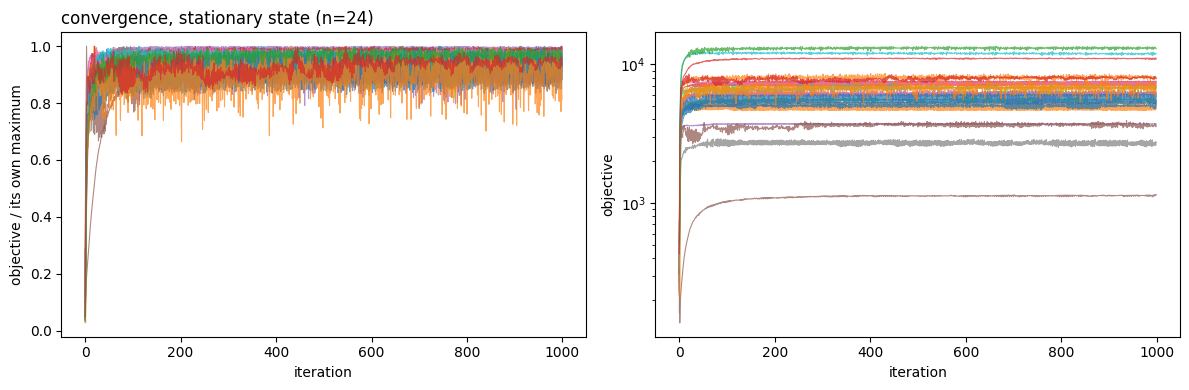

share of the total gain earned in the final 100 iterations:
  median -0.003%   max 8.477%
  (a few percent means the budget is comfortable; double digits means raise MAX_ITERATIONS)


In [11]:
# Did 1000 steps converge? `optimize_stimulus` records nothing, so this is the `TracedObjective` trace.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for bouton in top_boutons:
    trace = meis[(bouton, REFERENCE_STATE)]["trace"]
    axes[0].plot(trace / trace.max(), lw=0.8, alpha=0.7)
    axes[1].plot(trace, lw=0.8, alpha=0.7)

axes[0].set_ylabel("objective / its own maximum")
axes[0].set_title(f"convergence, {REFERENCE_STATE} state (n={len(top_boutons)})", loc="left")
axes[1].set_yscale("log")
axes[1].set_ylabel("objective")
for ax in axes:
    ax.set_xlabel("iteration")
plt.tight_layout()
plt.show()

# How much of the total gain arrives in the last tenth of the budget? If that is still large, the
# budget is the binding constraint and MAX_ITERATIONS is too low.
tail = max(1, MAX_ITERATIONS // 10)
tail_gain = np.array(
    [
        (record["trace"][-1] - record["trace"][-tail]) / (record["trace"][-1] - record["trace"][0])
        for record in meis.values()
    ]
)
print(f"share of the total gain earned in the final {tail} iterations:")
print(f"  median {np.median(tail_gain):.3%}   max {tail_gain.max():.3%}")
print("  (a few percent means the budget is comfortable; double digits means raise MAX_ITERATIONS)")

### Calibrating the remaining knobs

Four one-factor-at-a-time sweeps around the settings above, on a handful of boutons at the reference
state. One factor at a time rather than a grid, because the point is to see which knob moves
`autocorr_lag1` — the number that has to change if the MEI is to stop looking like noise — not to
find a joint optimum.

Read the tables together with the baseline row. `objective` in isolation is not the goal: a stimulus
at higher contrast will almost always drive the model harder while being less interpretable, which is
exactly the trade the contrast ladder is there to expose.

**On the smoothness weight.** `optimize_stimulus` minimizes `-objective + sum(regularizers)`, and
`SmoothnessRegularizationLoss` is normalized to be dimensionless and O(1). This model's responses are
O(10³), so the weight has to be O(10²–10³) to bite at all — the repo's habitual `factor=0.1` would do
nothing here even if the loss it was attached to had not been inert.

In [ ]:
# Four OFAT sweeps. Deliberately few boutons: 4 x 13 settings x MAX_ITERATIONS is already comparable
# to the whole run above, and the comparison between rungs is what carries the information.
SWEEP_BOUTONS = top_boutons[:4]
METRIC_KEYS = ("rms_inside", "clipped_frac", "norm_outside_frac", "autocorr_lag1", "rank1_frac")


def sweep_rows(label: str, **overrides) -> dict:
    """Run every SWEEP_BOUTON at one setting and average the metrics over them."""
    rows, stimuli = [], []
    for bouton in SWEEP_BOUTONS:
        stimulus, support, trace, best, learning_rate, _ = compute_mei(
            bouton, BEHAVIOR_STATES[REFERENCE_STATE], **overrides
        )
        rows.append(
            {
                "objective": best,
                "at_peak": trajectory_is_stable(trace),
                "lr": learning_rate,
                **mei_metrics(stimulus, support, min_max_values[0]),
            }
        )
        stimuli.append((stimulus, support))
    summary = {"label": label, "objective": float(np.mean([r["objective"] for r in rows]))}
    summary.update({key: float(np.mean([r[key] for r in rows])) for key in METRIC_KEYS})
    summary["at_peak"] = f"{sum(r['at_peak'] for r in rows)}/{len(rows)}"
    summary["stimuli"] = stimuli
    return summary


def print_table(title: str, rows: list[dict]) -> None:
    print(f"\n{title}")
    header = f"  {'setting':>16} {'objective':>10} {'rms_in':>7} {'clip':>6} {'outside':>8} {'r1':>6} {'rank1':>6} {'peak':>5}"
    print(header)
    print("  " + "-" * (len(header) - 2))
    for row in rows:
        print(
            f"  {row['label']:>16} {row['objective']:10.1f} {row['rms_inside']:7.2f}"
            f" {row['clipped_frac']:6.1%} {row['norm_outside_frac']:8.1%}"
            f" {row['autocorr_lag1']:+6.2f} {row['rank1_frac']:6.2f} {row['at_peak']:>5}"
        )


# --- Contrast: the norm target as a multiple of the training video's RMS -----------------------
contrast_rows = [sweep_rows(f"rms_factor={f}", rms_factor=f) for f in (0.1, 0.25, 0.5, 1.0)]
print_table("Contrast ladder (baseline is rms_factor=1.0)", contrast_rows)

# --- Smoothness: the prior that did not exist before ------------------------------------------
smoothness_rows = [
    sweep_rows(f"spatial={f:g}", smoothness_spatial=f) for f in (0.0, 1e2, 1e3, 1e4)
]
print_table("Spatial smoothness weight", smoothness_rows)

# --- Response window: 10 output frames is 53% of the model's 633 ms temporal RF ----------------
window_rows = [sweep_rows(f"window={w}", response_window=w) for w in (1, 3, 10)]
print_table("Response window length (output frames)", window_rows)

# --- Seed stability: the check that says whether any of this is an optimum ---------------------
seed_rows = [sweep_rows(f"seed={s}", seed=s) for s in (0, 1, 2)]
print_table("Seed stability", seed_rows)

# Pairwise MEI correlation across seeds, inside each bouton's support. This is the number that says
# whether the MEI is a stable optimum or one arbitrary point on the norm sphere.
correlations = []
for bouton_index in range(len(SWEEP_BOUTONS)):
    support = seed_rows[0]["stimuli"][bouton_index][1].numpy()
    flat = [
        row["stimuli"][bouton_index][0].numpy()[0, 0][:, support].ravel() for row in seed_rows
    ]
    for i in range(len(flat)):
        for j in range(i + 1, len(flat)):
            correlations.append(np.corrcoef(flat[i], flat[j])[0, 1])
print(
    f"\ncross-seed MEI correlation inside the support (n={len(correlations)} pairs): "
    f"median {np.median(correlations):+.3f}  min {np.min(correlations):+.3f}  max {np.max(correlations):+.3f}"
)
print("  ~1.0 = the optimization finds the same stimulus regardless of where it starts;")
print("  near 0 = each run reports a different arbitrary point and no single MEI should be shown.")

# Keep the stimuli, not just the metrics. The first version of this cell saved only the aggregate
# scalars, so the MEIs it computed at every ladder setting -- including the smooth ones the sweep
# points to -- were discarded and could only be recovered by re-running the whole thing on a GPU.
# (n_settings, n_boutons, T, H, W) per ladder; ~13 MB compressed for all four.
def stack_stimuli(rows: list[dict]) -> np.ndarray:
    return np.stack(
        [np.stack([stimulus.numpy()[0, 0] for stimulus, _ in row["stimuli"]]) for row in rows]
    ).astype(np.float32)


def stack_support(rows: list[dict]) -> np.ndarray:
    return np.stack([np.stack([support.numpy() for _, support in row["stimuli"]]) for row in rows])


save_arrays(
    "mei_knob_sweep",
    sweep_boutons=np.asarray(SWEEP_BOUTONS),
    cross_seed_correlation=np.asarray(correlations),
    **{
        f"{name}_{what}": stacker(rows)
        for name, rows in (
            ("contrast", contrast_rows),
            ("smoothness", smoothness_rows),
            ("window", window_rows),
            ("seed", seed_rows),
        )
        for what, stacker in (("stimuli", stack_stimuli), ("support", stack_support))
    },
    **{
        f"{name}_{key}": np.asarray([row[key] for row in rows])
        for name, rows in (
            ("contrast", contrast_rows),
            ("smoothness", smoothness_rows),
            ("window", window_rows),
            ("seed", seed_rows),
        )
        for key in ("objective", *METRIC_KEYS)
    },
    **{
        f"{name}_labels": np.asarray([row["label"] for row in rows])
        for name, rows in (
            ("contrast", contrast_rows),
            ("smoothness", smoothness_rows),
            ("window", window_rows),
            ("seed", seed_rows),
        )
    },
)

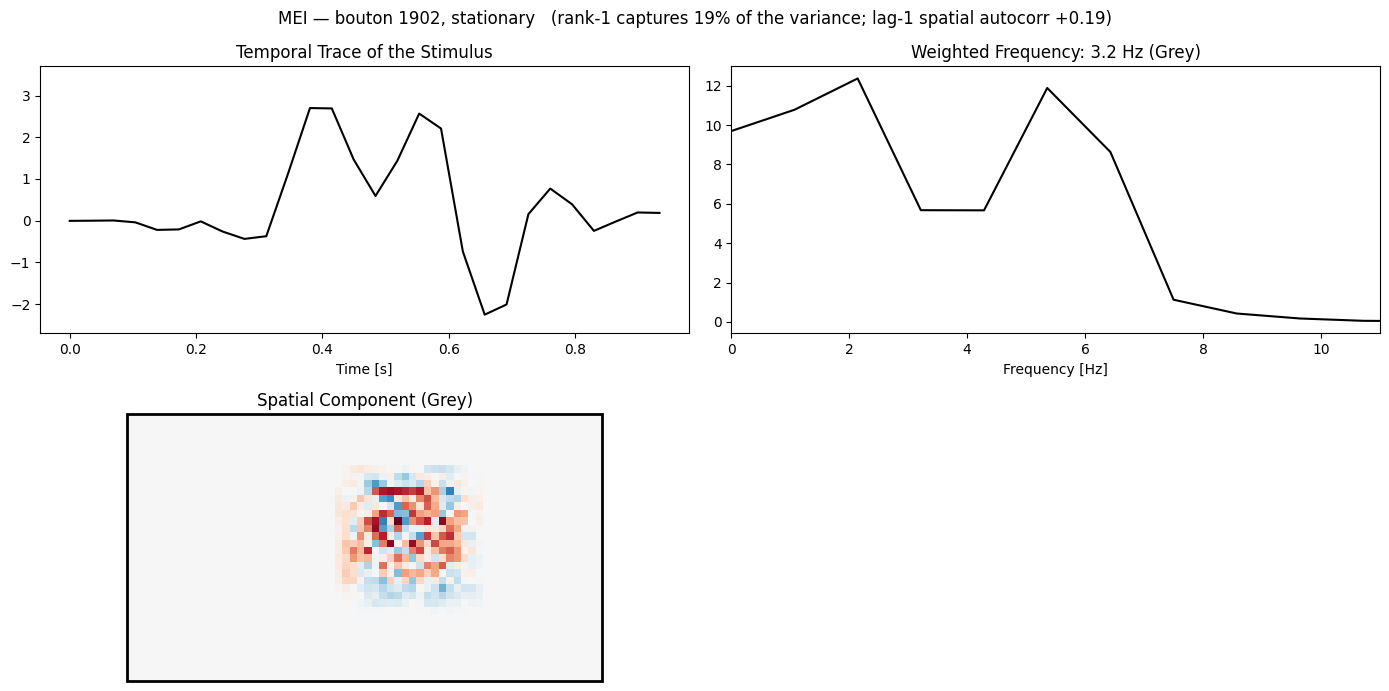

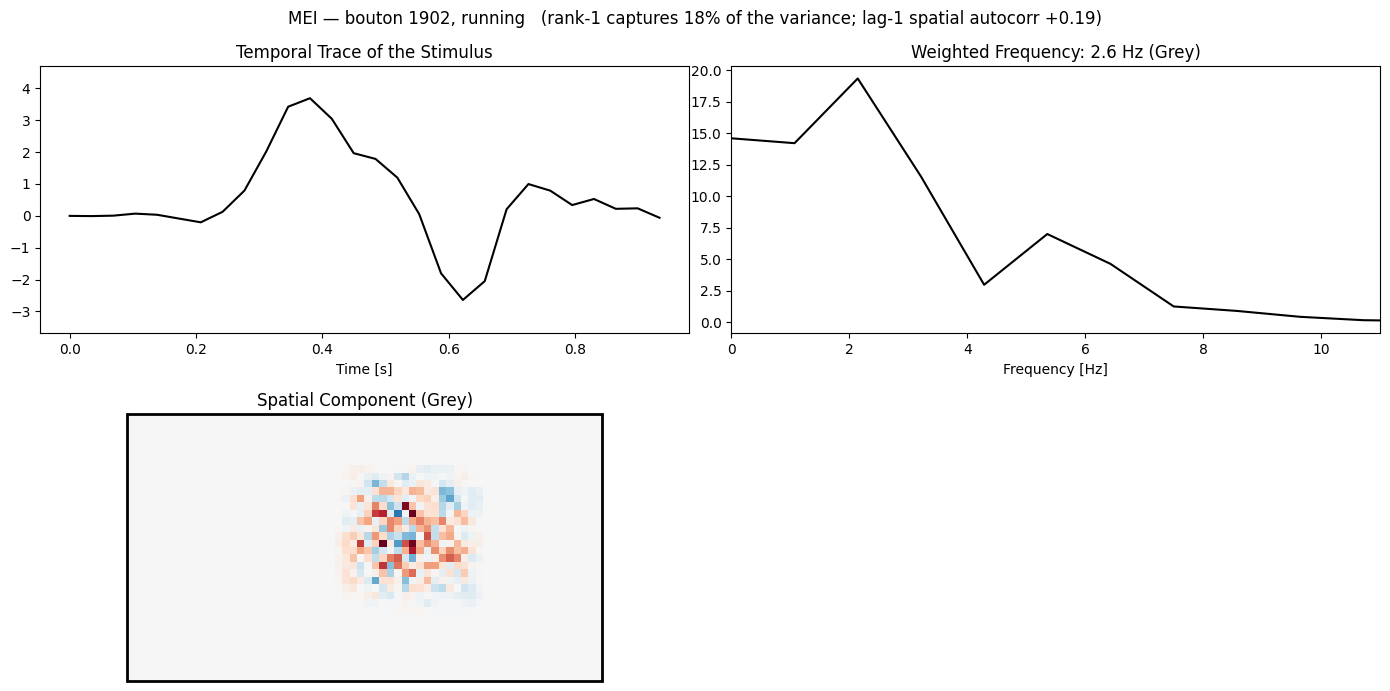

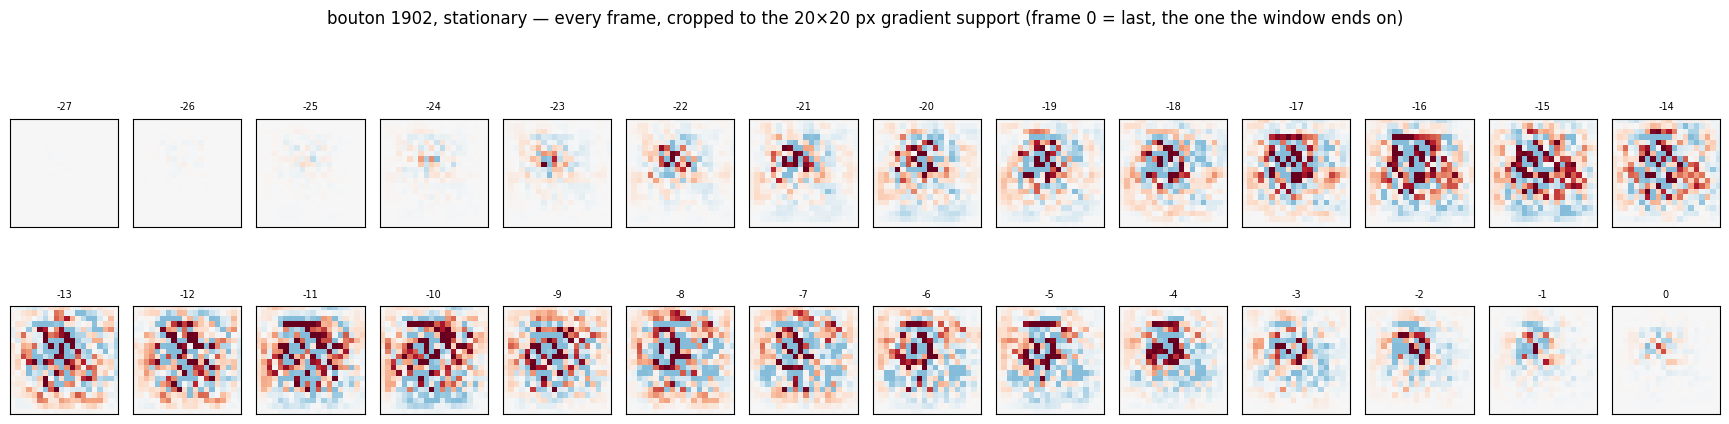

In [13]:
from openretina.utils.plotting import plot_stimulus_composition

# The optimized tensor is single-channel, so `plot_stimulus_composition` takes its greyscale path
# automatically. (Handing it 3 channels would run an SVD on the spatially-constant behavior channels,
# and at exactly 0.0 that divides by zero in video_analysis.py.) `scale_bar_label=None` because the
# bar's width is hard-coded for the hoefling retina geometry and means nothing here.
#
# The spatial panel is the *leading singular vector* of the whole tensor, so it is only a fair summary
# to the extent the MEI is space-time separable -- `rank1_frac` says how far that is true, printed
# next to each figure. Below it, the raw frames, which need no separability assumption at all.
bouton = top_boutons[0]
for state_name in BEHAVIOR_STATES:
    record = meis[(bouton, state_name)]
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    plot_stimulus_composition(
        stimulus=record["stimulus"][0],
        temporal_trace_ax=axes[0, 0],
        freq_ax=axes[0, 1],
        spatial_ax=axes[1, 0],
        scale_bar_label=None,
    )
    axes[1, 1].axis("off")
    fig.suptitle(
        f"MEI — bouton {bouton}, {state_name}   "
        f"(rank-1 captures {record['rank1_frac']:.0%} of the variance; "
        f"lag-1 spatial autocorr {record['autocorr_lag1']:+.2f})"
    )
    plt.tight_layout()
    plt.show()

# Every frame, cropped to the bouton's gradient support, with the surround marked. No rank-1
# assumption, and the crop is where the MEI actually lives.
record = meis[(bouton, REFERENCE_STATE)]
frames = record["stimulus"][0, 0].numpy()
rows, cols = np.nonzero(record["support"].numpy())
crop = frames[:, rows.min() : rows.max() + 1, cols.min() : cols.max() + 1]
limit = np.abs(crop).max()

fig, axes = plt.subplots(2, (MEI_TIME_STEPS + 1) // 2, figsize=(1.1 * MEI_TIME_STEPS / 2 + 2, 5))
for frame_index, ax in enumerate(axes.ravel()):
    if frame_index >= MEI_TIME_STEPS:
        ax.axis("off")
        continue
    ax.imshow(crop[frame_index], cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(f"{frame_index - MEI_TIME_STEPS + 1}", fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(
    f"bouton {bouton}, {REFERENCE_STATE} — every frame, cropped to the {crop.shape[1]}×{crop.shape[2]} px"
    f" gradient support (frame 0 = last, the one the window ends on)"
)
plt.tight_layout()
plt.show()

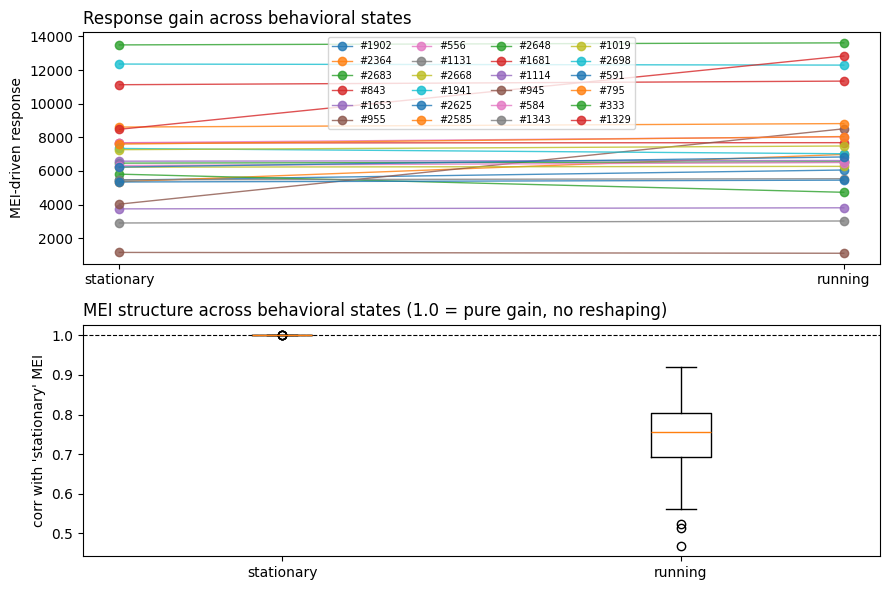

median similarity per state: {'stationary': np.float64(1.0), 'running': np.float64(0.756)}


In [14]:
# Does the behavior state rescale the MEI, or reshape it?
fig, axes = plt.subplots(2, 1, figsize=(9, 6))
state_names = list(BEHAVIOR_STATES)

for bouton in top_boutons:
    responses = np.array([meis[(bouton, s)]["after"] for s in state_names])
    axes[0].plot(range(len(state_names)), responses, marker="o", lw=1, alpha=0.8, label=f"#{bouton}")

axes[0].set_xticks(range(len(state_names)), state_names)
axes[0].set_ylabel("MEI-driven response")
axes[0].set_title("Response gain across behavioral states", loc="left")
axes[0].legend(fontsize=7, ncol=4)

# Spatial correlation between each state's MEI and the mean-state MEI, per bouton.
reference_state = REFERENCE_STATE
similarity = np.array(
    [
        [
            float(
                torch.corrcoef(
                    torch.stack(
                        [
                            meis[(bouton, s)]["stimulus"].flatten(),
                            meis[(bouton, reference_state)]["stimulus"].flatten(),
                        ]
                    )
                )[0, 1]
            )
            for s in state_names
        ]
        for bouton in top_boutons
    ]
)
axes[1].boxplot([similarity[:, i] for i in range(len(state_names))], tick_labels=state_names)
axes[1].axhline(1.0, color="k", ls="--", lw=0.8)
axes[1].set_ylabel(f"corr with '{reference_state}' MEI")
axes[1].set_title("MEI structure across behavioral states (1.0 = pure gain, no reshaping)", loc="left")
plt.tight_layout()
plt.show()

print("median similarity per state:", dict(zip(state_names, np.median(similarity, axis=0).round(3))))

## 2. Behavior-state modulation

`behavior_response_grid` holds one video fixed and sweeps the two behavior channels over a
17 × 17 grid spanning ±2 standard deviations, reducing each response over time.

Two probes, because the answer can depend on the stimulus: a bouton's own MEI (a strongly driving
input) and mid-grey (no drive at all, isolating the pure behavioral bias).

In [15]:
from openretina.insilico import MeanReducer, ResponseGrid, behavior_response_grid

reference_state = REFERENCE_STATE
probe_bouton = top_boutons[0]
mei_video = meis[(probe_bouton, reference_state)]["stimulus"][0, 0]        # (t, h, w)
grey_video = torch.zeros_like(mei_video)                                    # z-scored mid-grey

grids = {}
for probe_name, probe_video in [("MEI", mei_video), ("grey", grey_video)]:
    grids[probe_name] = behavior_response_grid(
        model,
        SESSION,
        probe_video,
        response_reducer=MeanReducer(axis=0),
        behavior_channels=BEHAVIOR_CHANNELS,
        pupil_center=PUPIL_CENTER,
        neuron_indices=top_boutons,
        device=device,
    )
    print(f"{probe_name:5s}: responses {grids[probe_name].responses.shape}")

for probe_name, grid in grids.items():
    print(f"  saved {grid.save(RESULTS_DIR / f'grid_sampled_{probe_name}').name}")

MEI  : responses (17, 17, 24)


grey : responses (17, 17, 24)
  saved grid_sampled_MEI.npz
  saved grid_sampled_grey.npz


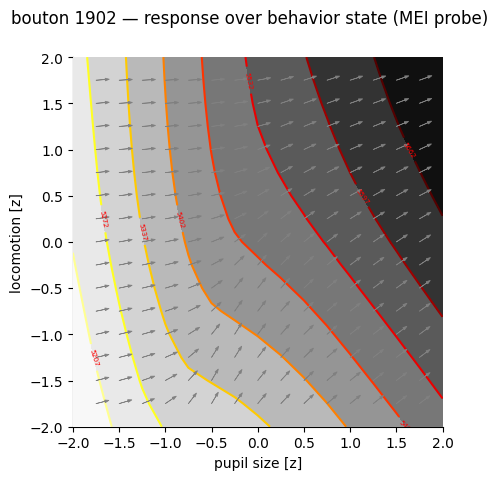

In [16]:
from openretina.utils.plotting import plot_vector_field_resp_iso

# `for_neuron` returns exactly the layout this plot expects. `tick_locations=None` matters: the
# default FixedLocator([-1, 0, 1]) is calibrated for the chromatic-contrast grid and would put all
# three ticks near the middle of a -2..+2 sweep.
grid = grids["MEI"]
neuron_slot = 0  # index into `top_boutons`
responses, gradients = grid.for_neuron(neuron_slot)

figure = plot_vector_field_resp_iso(
    grid.axis_values[0],
    grid.axis_values[1],
    gradients,
    responses,
    xlabel=grid.axis_names[0],
    ylabel=grid.axis_names[1],
    tick_locations=None,
)
figure.suptitle(f"bouton {top_boutons[neuron_slot]} — response over behavior state (MEI probe)")
plt.show()

### The grid visits states the animal never produced

A rectangular sweep necessarily includes combinations like pupil `+2` with locomotion `−2`. The
empirical joint density says which parts of the grid are actually supported; read the corners with
that in mind.

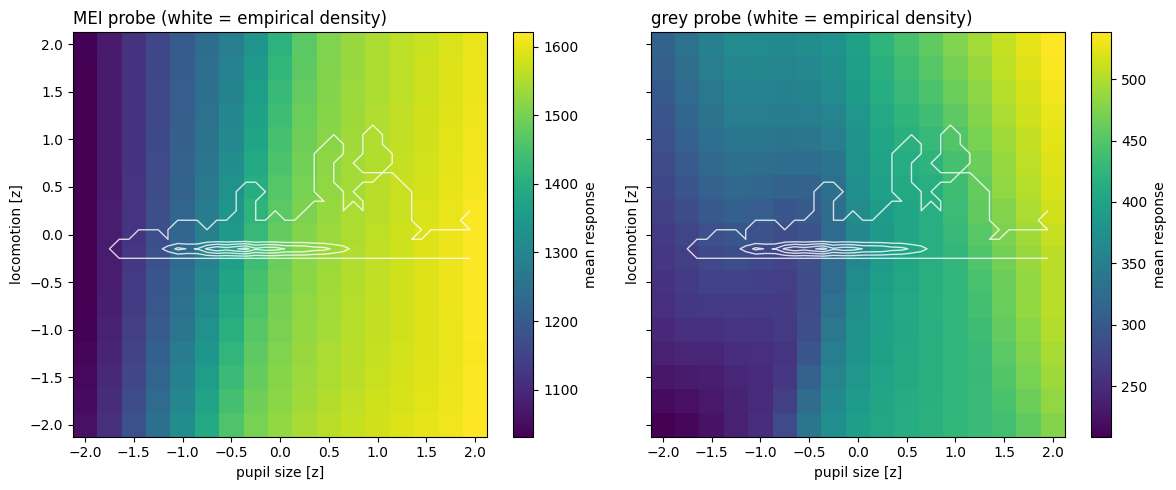

93.4% of recorded frames fall inside the swept +/-2 z range


In [17]:
# Empirical joint density of the two behavior channels. `behavior_trace` was captured further up,
# before the dataloader build released the movies.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
edges = np.linspace(-2, 2, 41)

for ax, (probe_name, grid) in zip(axes, grids.items()):
    mean_response = grid.responses.mean(axis=-1)  # averaged over the sampled boutons
    mesh = ax.pcolormesh(
        grid.axis_values[0], grid.axis_values[1], mean_response.T, shading="nearest", cmap="viridis"
    )
    ax.contour(
        *np.meshgrid(0.5 * (edges[:-1] + edges[1:]), 0.5 * (edges[:-1] + edges[1:]), indexing="ij"),
        np.histogram2d(behavior_trace[0], behavior_trace[1], bins=[edges, edges])[0],
        levels=4,
        colors="white",
        linewidths=1.0,
        alpha=0.8,
    )
    fig.colorbar(mesh, ax=ax, label="mean response")
    ax.set_xlabel(grid.axis_names[0])
    ax.set_ylabel(grid.axis_names[1])
    ax.set_title(f"{probe_name} probe (white = empirical density)", loc="left")

plt.tight_layout()
plt.show()

in_range = ((np.abs(behavior_trace) <= 2).all(axis=0)).mean()
print(f"{in_range:.1%} of recorded frames fall inside the swept +/-2 z range")

MEI  : 2710/2710 finite | median 0.301
grey : 2710/2710 finite | median 0.280


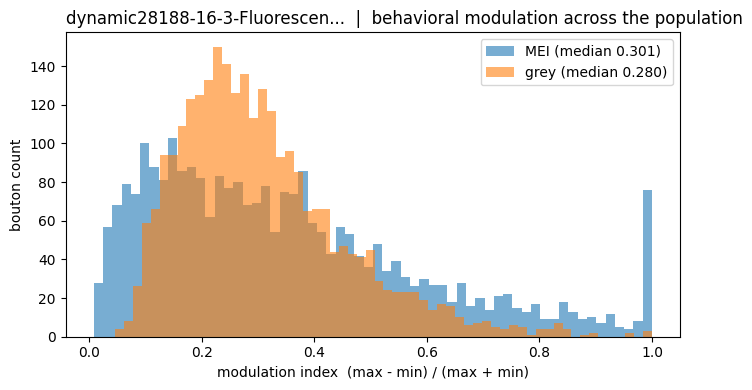

  saved grid_population_MEI.npz


  saved grid_population_grey.npz


In [18]:
# Population modulation index over ALL boutons of this session, on both probes.
population_grids = {
    probe_name: behavior_response_grid(
        model,
        SESSION,
        probe_video,
        response_reducer=MeanReducer(axis=0),
        behavior_channels=BEHAVIOR_CHANNELS,
        pupil_center=PUPIL_CENTER,
        compute_gradients=False,   # not needed for the index, and it doubles the memory
        device=device,
    )
    for probe_name, probe_video in [("MEI", mei_video), ("grey", grey_video)]
}

plt.figure(figsize=(7, 4))
for probe_name, grid in population_grids.items():
    index = grid.modulation_index()
    finite = index[np.isfinite(index)]
    plt.hist(finite, bins=60, alpha=0.6, label=f"{probe_name} (median {np.median(finite):.3f})")
    print(f"{probe_name:5s}: {len(finite)}/{len(index)} finite | median {np.median(finite):.3f}")

plt.xlabel("modulation index  (max - min) / (max + min)")
plt.ylabel("bouton count")
plt.title(f"{SESSION[:28]}...  |  behavioral modulation across the population", loc="left")
plt.legend()
plt.tight_layout()
plt.show()

for probe_name, grid in population_grids.items():
    print(f"  saved {grid.save(RESULTS_DIR / f'grid_population_{probe_name}').name}")

## 3. The pupil shifter: how far does it move a receptive field?

`shifter_shift_grid` evaluates the shifter MLPs directly — no core, no readout, milliseconds for all
10 sessions. That answers the displacement question without the confound of a response.

The shift is in normalized grid units; `shift_to_core_pixels` converts to core-output pixels. Note
the last-axis order is `(width, height)`, because `grid_sample` reads `grid[..., 0]` as x.

In [19]:
from openretina.insilico import shift_to_core_pixels, shifter_shift_grid

shifts = shifter_shift_grid(model, device=device)

# The core's output spatial shape sets the pixel conversion.
with torch.no_grad():
    probe = torch.zeros(model.stimulus_shape(MEI_TIME_STEPS), device=device)
    core_output_shape = tuple(model.core(probe).shape[-2:])
print("core output (h, w):", core_output_shape)

rows = []
for session, shift in shifts.items():
    pixels = shift_to_core_pixels(shift, core_output_shape, align_corners=model.readout[session].align_corners)
    displacement = np.linalg.norm(pixels, axis=-1)
    rows.append((session, displacement.max(), np.abs(pixels[..., 0]).max(), np.abs(pixels[..., 1]).max()))

print(f"\n{'session':<44}{'max |shift|':>12}{'max dx':>9}{'max dy':>9}   (core pixels)")
for session, total, dx, dy in rows:
    print(f"{session[:42]:<44}{total:>12.2f}{dx:>9.2f}{dy:>9.2f}")

save_arrays(
    "shifter",
    sessions=np.asarray(list(shifts)),
    shifts=np.stack([shifts[s] for s in shifts]),
    align_corners=np.asarray([model.readout[s].align_corners for s in shifts]),
    core_output_shape=np.asarray(core_output_shape),
    pupil_values=np.linspace(*BEHAVIOR_SWEEP_RANGE, next(iter(shifts.values())).shape[0]),
)

core output (h, w): (18, 46)

session                                      max |shift|   max dx   max dy   (core pixels)
dynamic28188-16-3-Fluorescence-7b721b-v4a           2.99     2.91     1.44
dynamic28188-16-5-Fluorescence-7b721b-v4a           3.05     3.04     1.34
dynamic28188-17-2-Fluorescence-7b721b-v4a           4.53     3.98     3.25
dynamic28188-18-4-Fluorescence-7b721b-v4a           5.10     2.62     4.44
dynamic28188-19-9-Fluorescence-7b721b-v4a           2.46     2.45     1.77
dynamic28712-3-8-Fluorescence-7b721b-v4a            7.55     5.38     6.52
dynamic29163-2-7-Fluorescence-7b721b-v4a            5.23     4.98     1.59
dynamic29163-4-4-Fluorescence-7b721b-v4a            3.25     3.22     0.44
dynamic29163-5-8-Fluorescence-7b721b-v4a            2.29     2.26     0.35
dynamic29163-6-5-Fluorescence-7b721b-v4a            2.53     2.11     2.10
  saved shifter.npz                   0.02 MB


PosixPath('/mnt/lustre/work/bethge/bkr578/projects/open-retina/openretina_assets/insilico/qiu_2026/dynamic28188-16-3-Fluorescence-7b721b-v4a/shifter.npz')

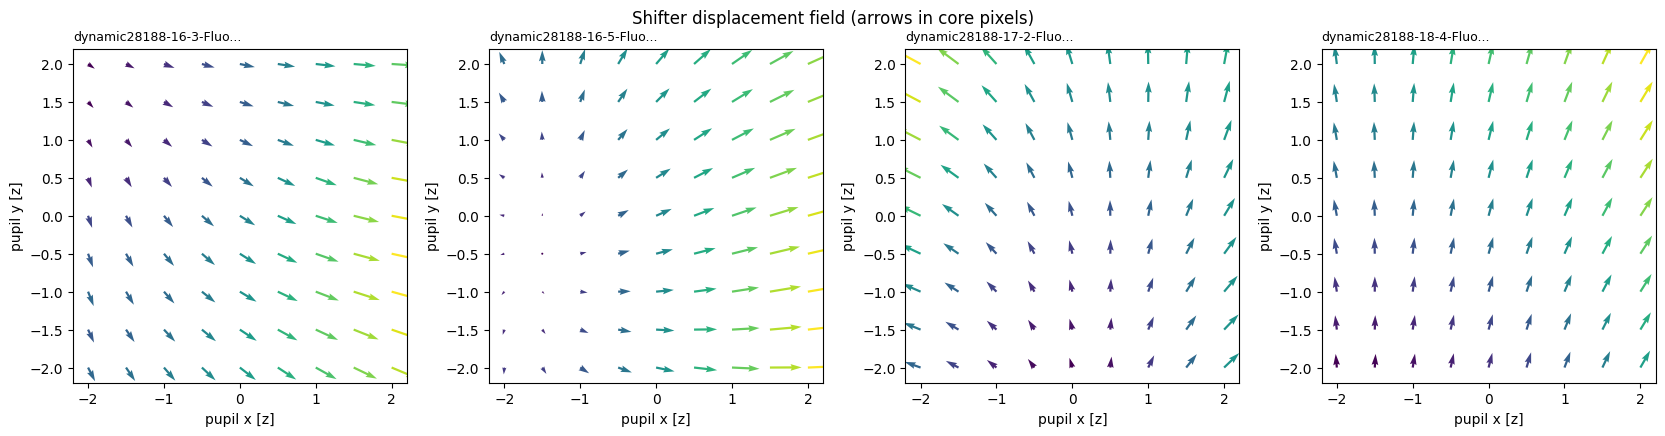

In [20]:
# Quiver of the shift field for a few sessions.
n_show = min(4, len(shifts))
fig, axes = plt.subplots(1, n_show, figsize=(4.2 * n_show, 4.2), squeeze=False)
step = 2  # thin the 17x17 grid so the arrows stay readable

for ax, (session, shift) in zip(axes[0], list(shifts.items())[:n_show]):
    pixels = shift_to_core_pixels(shift, core_output_shape, align_corners=model.readout[session].align_corners)
    values = np.linspace(*BEHAVIOR_SWEEP_RANGE, shift.shape[0])
    mesh_x, mesh_y = np.meshgrid(values, values, indexing="ij")
    ax.quiver(
        mesh_x[::step, ::step], mesh_y[::step, ::step],
        pixels[::step, ::step, 0], pixels[::step, ::step, 1],
        np.linalg.norm(pixels[::step, ::step], axis=-1),
        cmap="viridis", angles="xy",
    )
    ax.set_xlabel("pupil x [z]")
    ax.set_ylabel("pupil y [z]")
    ax.set_title(session[:22] + "...", fontsize=9, loc="left")
    ax.set_aspect("equal")

fig.suptitle("Shifter displacement field (arrows in core pixels)")
plt.tight_layout()
plt.show()

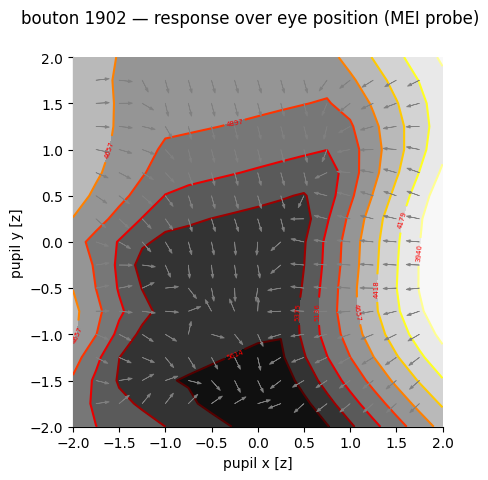

eye-position modulation index for the sampled boutons: [0.225 0.234 0.304 0.473 0.17  0.428 0.423 0.333 0.122 0.244 0.253 0.316
 0.115 0.345 0.235 0.979 0.239 0.136 0.191 0.448 0.214 0.263 0.311 0.389]
  saved grid_pupil_center.npz


In [21]:
# What does that displacement cost in response terms?
from openretina.insilico import pupil_center_response_grid

# The full model input this time -- behavior channels included, since they are held fixed here.
full_stimulus = torch.zeros(model.stimulus_shape(MEI_TIME_STEPS)[1:])
full_stimulus[0] = mei_video
full_stimulus[BEHAVIOR_CHANNELS[0]] = 0.0
full_stimulus[BEHAVIOR_CHANNELS[1]] = 0.0

pupil_grid = pupil_center_response_grid(
    model,
    SESSION,
    full_stimulus,
    response_reducer=MeanReducer(axis=0),
    neuron_indices=top_boutons,
    device=device,
)

responses, gradients = pupil_grid.for_neuron(0)
figure = plot_vector_field_resp_iso(
    pupil_grid.axis_values[0],
    pupil_grid.axis_values[1],
    gradients,
    responses,
    xlabel=pupil_grid.axis_names[0],
    ylabel=pupil_grid.axis_names[1],
    tick_locations=None,
)
figure.suptitle(f"bouton {top_boutons[0]} — response over eye position (MEI probe)")
plt.show()

index = pupil_grid.modulation_index()
print("eye-position modulation index for the sampled boutons:", np.round(index, 3))

print(f"  saved {pupil_grid.save(RESULTS_DIR / 'grid_pupil_center').name}")

**Reading the eye-position sweep.** The shift is added *after* `mu` is clamped to `[-1, 1]`, so a
large enough shift pushes a bouton off the feature map and its response collapses. A plateau at the
edge of this grid is a property of the readout, not a tuning curve.

## Summary

- MEI amplitude changes with behavioral state while MEI structure stays nearly fixed — the gain-only
  prediction the architecture makes, now measured rather than assumed.
- The population modulation index quantifies how much of that gain there is, and the empirical
  density overlay marks which parts of the sweep the animal actually visited.
- The shifter's displacement, in core pixels, says whether eye-movement compensation is a
  few-pixel correction or something larger.

## 4. Reloading these results without re-running anything

Everything above is on disk. The cell below reloads it *from the files alone* -- no model, no GPU,
no dataset -- and re-plots two figures, so the roundtrip is verified rather than asserted.

`qiu_2026_insilico_from_disk.ipynb` is exactly that, already written: the same analyses and the
same figures, reading these files. Its figures are byte-identical to the ones above.

```
openretina_assets/insilico/qiu_2026/<session>/
  metadata.json            run parameters: checkpoint, behavior states, MEI settings, constants
  boutons.npz              val_corr (all boutons), top_boutons (the ones with MEIs)
  meis.npz                 stimuli (n_boutons, n_states, T, H, W) + before/after/lr per MEI
  grid_sampled_{MEI,grey}.npz      behavior sweep, sampled boutons, with gradients
  grid_population_{MEI,grey}.npz   behavior sweep, all boutons, no gradients
  grid_pupil_center.npz    eye-position sweep
  shifter.npz              per-session shift fields, align_corners, core output shape
  behavior_trace.npz       recorded behavior, for the empirical-density overlay
```

In [4]:
# --- Reload from disk only. Everything below is prefixed `re_` so it cannot silently reuse
# --- a variable that is still in this kernel's memory.
import json
from pathlib import Path

import numpy as np
from openretina.insilico import ResponseGrid, shift_to_core_pixels

re_dir = Path("openretina_assets/insilico/qiu_2026") / SESSION #RESULTS_DIR  # in a fresh kernel: Path("openretina_assets/insilico/qiu_2026") / SESSION

re_meta = json.loads((re_dir / "metadata.json").read_text())
re_meis = np.load(re_dir / "meis.npz")
re_boutons = np.load(re_dir / "boutons.npz")
re_shifter = np.load(re_dir / "shifter.npz")
re_grids = {n: ResponseGrid.load(re_dir / f"grid_sampled_{n}.npz") for n in ("MEI", "grey")}
re_population = {n: ResponseGrid.load(re_dir / f"grid_population_{n}.npz") for n in ("MEI", "grey")}
re_pupil = ResponseGrid.load(re_dir / "grid_pupil_center.npz")

re_states = [str(s) for s in re_meis["state_names"]]
print("checkpoint :", Path(re_meta["checkpoint"]).name)
print("session    :", re_meta["session"])
print("MEIs       :", re_meis["stimuli"].shape, "(boutons, states, T, H, W)  states:", re_states)
print("boutons    :", re_boutons["val_corr"].shape[0], "scored,", re_boutons["top_boutons"].shape[0], "with MEIs")
print("grids      :", {k: v.responses.shape for k, v in re_grids.items()})
print("population :", {k: v.responses.shape for k, v in re_population.items()})
print("shifter    :", re_shifter["shifts"].shape, "for", len(re_shifter["sessions"]), "sessions")

# The reloaded arrays must equal what is still in memory -- this is the actual roundtrip check.
assert np.array_equal(re_boutons["top_boutons"], np.asarray(top_boutons))
np.testing.assert_array_equal(re_grids["MEI"].responses, grids["MEI"].responses)
np.testing.assert_allclose(
    re_meis["stimuli"][0, 0], meis[(top_boutons[0], re_states[0])]["stimulus"].numpy()[0, 0], rtol=0, atol=0
)
print("\nroundtrip verified: reloaded arrays are identical to the in-memory ones")

TypeError: unsupported operand type(s) for /: 'PosixPath' and 'NoneType'

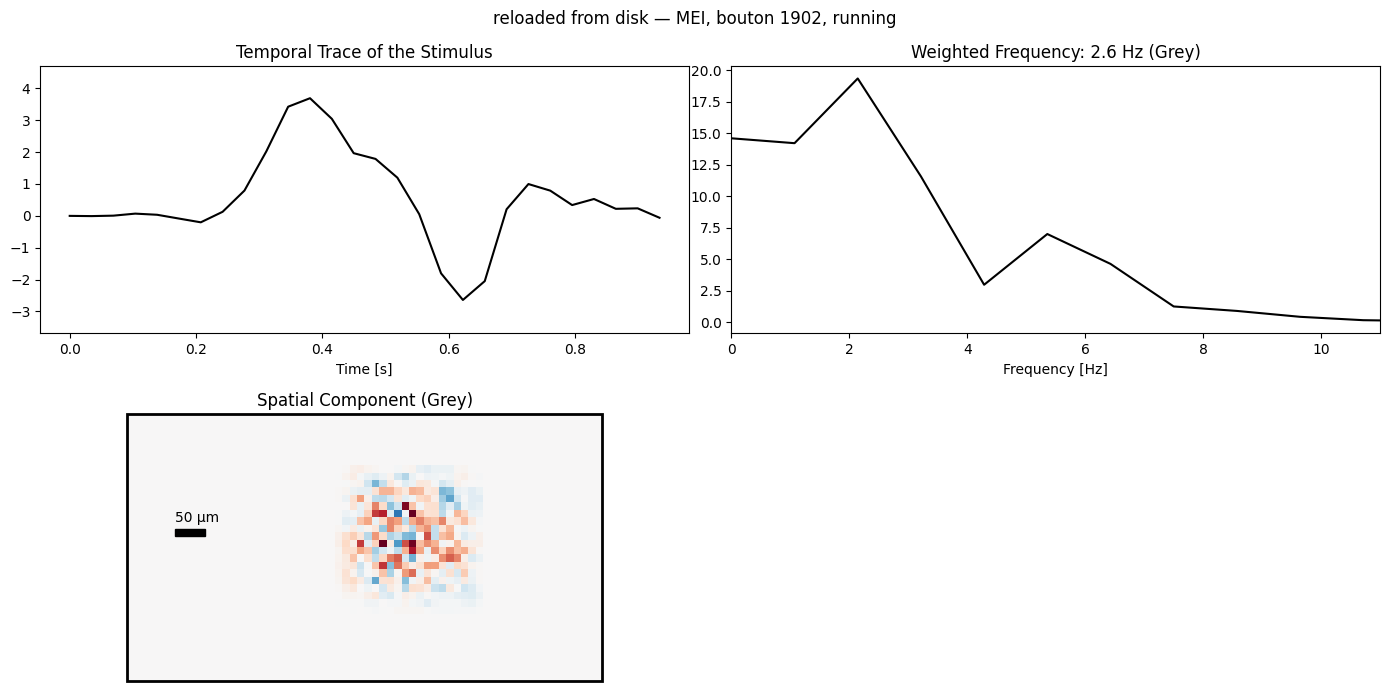

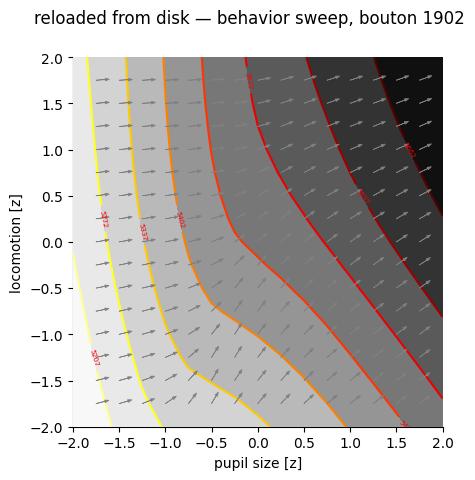

dynamic28188-16-3-Fluorescence-7b7: max displacement 2.99 px


In [23]:
# Re-plot straight from the reloaded arrays, using no model and no GPU.
from openretina.utils.plotting import plot_stimulus_composition, plot_vector_field_resp_iso

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
plot_stimulus_composition(
    stimulus=torch.from_numpy(re_meis["stimuli"][0, 1])[None],  # (1, T, H, W): bouton 0, mean state
    temporal_trace_ax=axes[0, 0],
    freq_ax=axes[0, 1],
    spatial_ax=axes[1, 0],
)
axes[1, 1].axis("off")
fig.suptitle(f"reloaded from disk — MEI, bouton {re_meis['bouton_ids'][0]}, {re_states[1]}")
plt.tight_layout()
plt.show()

re_responses, re_gradients = re_grids["MEI"].for_neuron(0)
figure = plot_vector_field_resp_iso(
    re_grids["MEI"].axis_values[0],
    re_grids["MEI"].axis_values[1],
    re_gradients,
    re_responses,
    xlabel=re_grids["MEI"].axis_names[0],
    ylabel=re_grids["MEI"].axis_names[1],
    tick_locations=None,
)
figure.suptitle(f"reloaded from disk — behavior sweep, bouton {re_meis['bouton_ids'][0]}")
plt.show()

# Shifter displacement, recomputed in pixels from the saved normalized shifts.
re_pixels = shift_to_core_pixels(
    re_shifter["shifts"][0], re_shifter["core_output_shape"], align_corners=bool(re_shifter["align_corners"][0])
)
print(f"{str(re_shifter['sessions'][0])[:34]}: max displacement {np.linalg.norm(re_pixels, axis=-1).max():.2f} px")